Install all the required packages for the notebook

In [74]:
!pip install -r requirements.txt

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Utilities: Data splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Data Balancing
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Utility Libraries
from functools import reduce
import string

# Evaluation Metrics and Visualization
from sklearn.metrics import accuracy_score, precision_score, \
    recall_score, roc_auc_score, f1_score, classification_report, \
    roc_curve, auc, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

In [2]:
# Load datasets
df = pd.read_csv('dataset/diabetic_data.csv')
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Exploratory Data Analysis (EDA)

In [3]:
df_eda = df.copy()

In [4]:
df_eda.describe().style.format("{:.2f}")

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,165201645.62,54330400.69,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,102640295.98,38696359.35,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,12522.00,135.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,84961194.00,23413221.00,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,152388987.00,45505143.00,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,230270887.50,87545949.75,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,443867222.00,189502619.00,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


In [5]:
df_eda.select_dtypes(include=['object', 'category']).describe()

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


Check if there are any duplicated rows

In [6]:
df_eda.duplicated().any()

False

A patient could have more encounters. This is not a case of duplication and is totally valid.

In [7]:
print(
    f"Total number of encounters: {len(df_eda.encounter_id.unique())}\nTotal number of patients: {len(df_eda.patient_nbr.unique())}")

Total number of encounters: 101766
Total number of patients: 71518


In [8]:
df_eda.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [9]:
df_eda.dtypes.value_counts()

object    37
int64     13
Name: count, dtype: int64

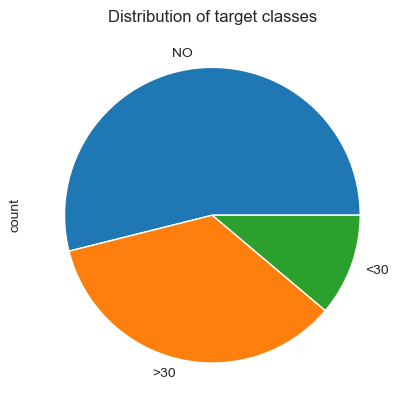

In [10]:
df_eda.readmitted.value_counts().plot(kind='pie', title='Distribution of target classes');

In [11]:
df_eda.readmitted.value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

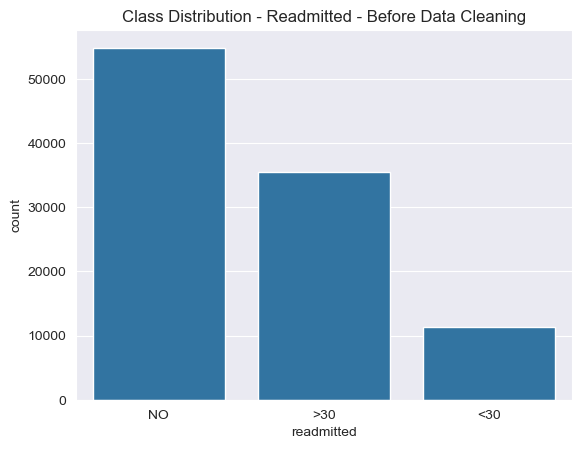

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

In [12]:
sns.countplot(x='readmitted', data=df_eda)
plt.title('Class Distribution - Readmitted - Before Data Cleaning')
plt.show()

df_eda['readmitted'].value_counts(normalize=True)

The dataset contains 3 classes for readmitted column : NO, >30 and <30. We are going to convert this into binary classes by mapping
NO into 0 and 1 for everything else

In [13]:
df_eda['label'] = df_eda.readmitted.apply(lambda x: 1 if x == '<30' else 0)

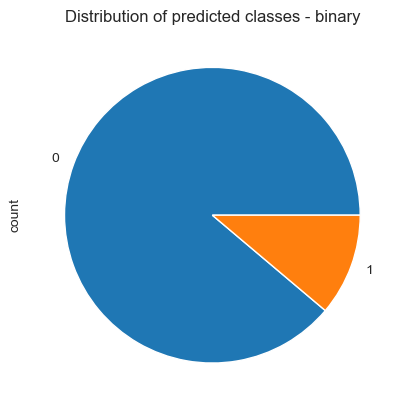

In [14]:
df_eda.label.value_counts().plot(kind='pie', title='Distribution of predicted classes - binary');

In [15]:
df_eda.label.value_counts()

label
0    90409
1    11357
Name: count, dtype: int64

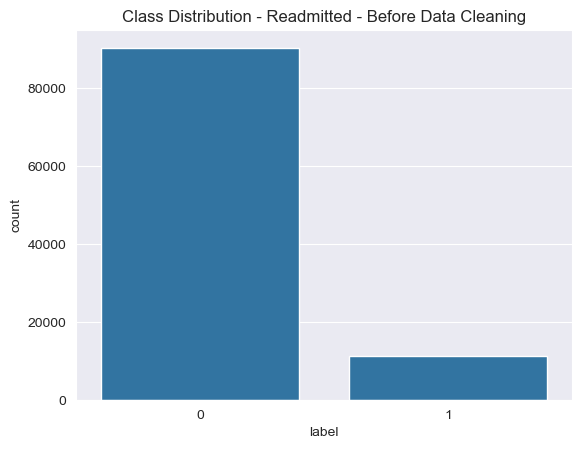

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

In [16]:
sns.countplot(x='label', data=df_eda)
plt.title('Class Distribution - Readmitted - Before Data Cleaning')
plt.show()

df_eda['readmitted'].value_counts(normalize=True)

The above charts clearly shows us the imbalance between the number of classes in our data. Only about 10% of the total data is positive.
We will handle this later by using methods like oversampling or undersampling.

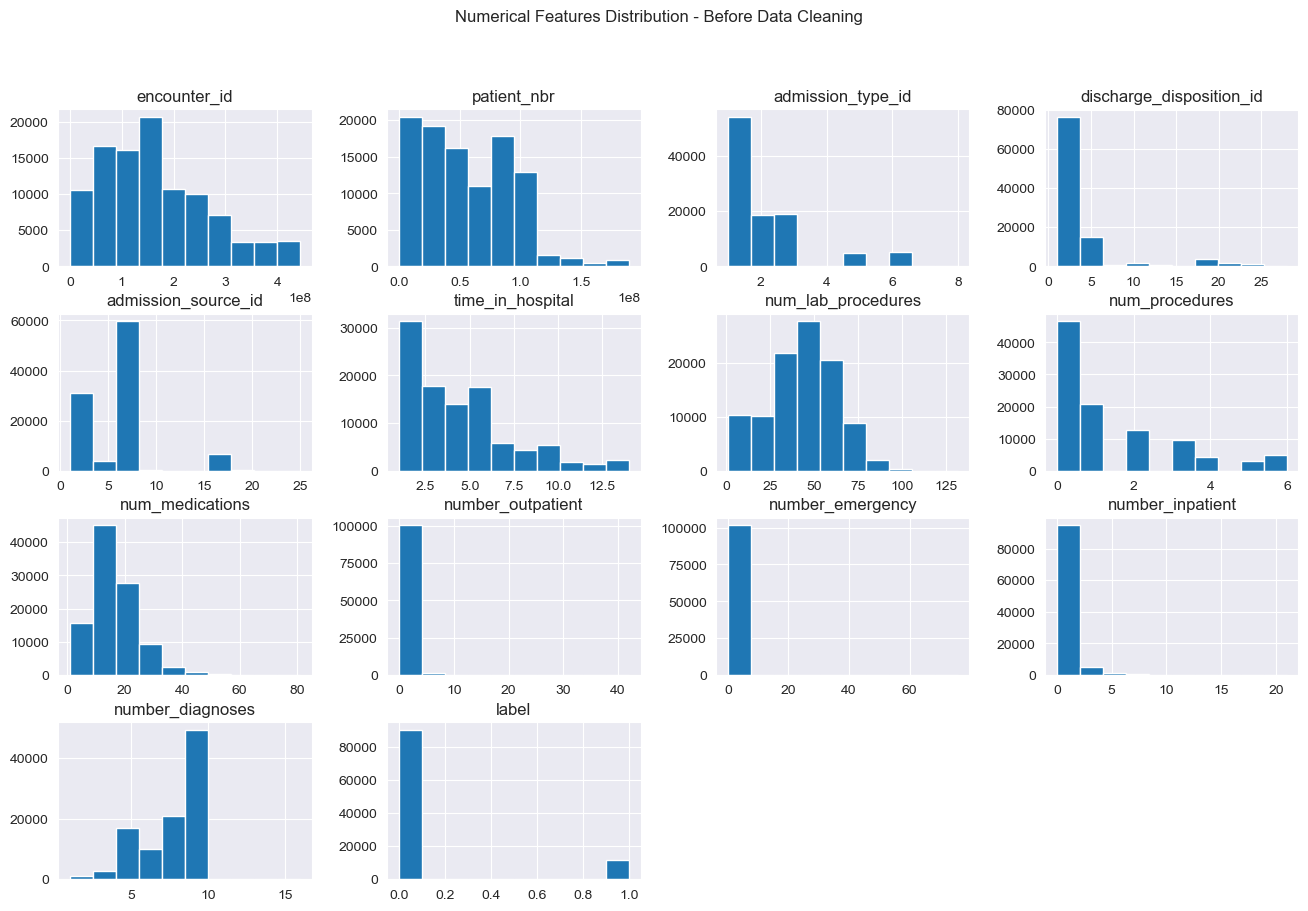

In [17]:
df_eda.hist(figsize=(16, 10))
plt.suptitle('Numerical Features Distribution - Before Data Cleaning')
plt.show()

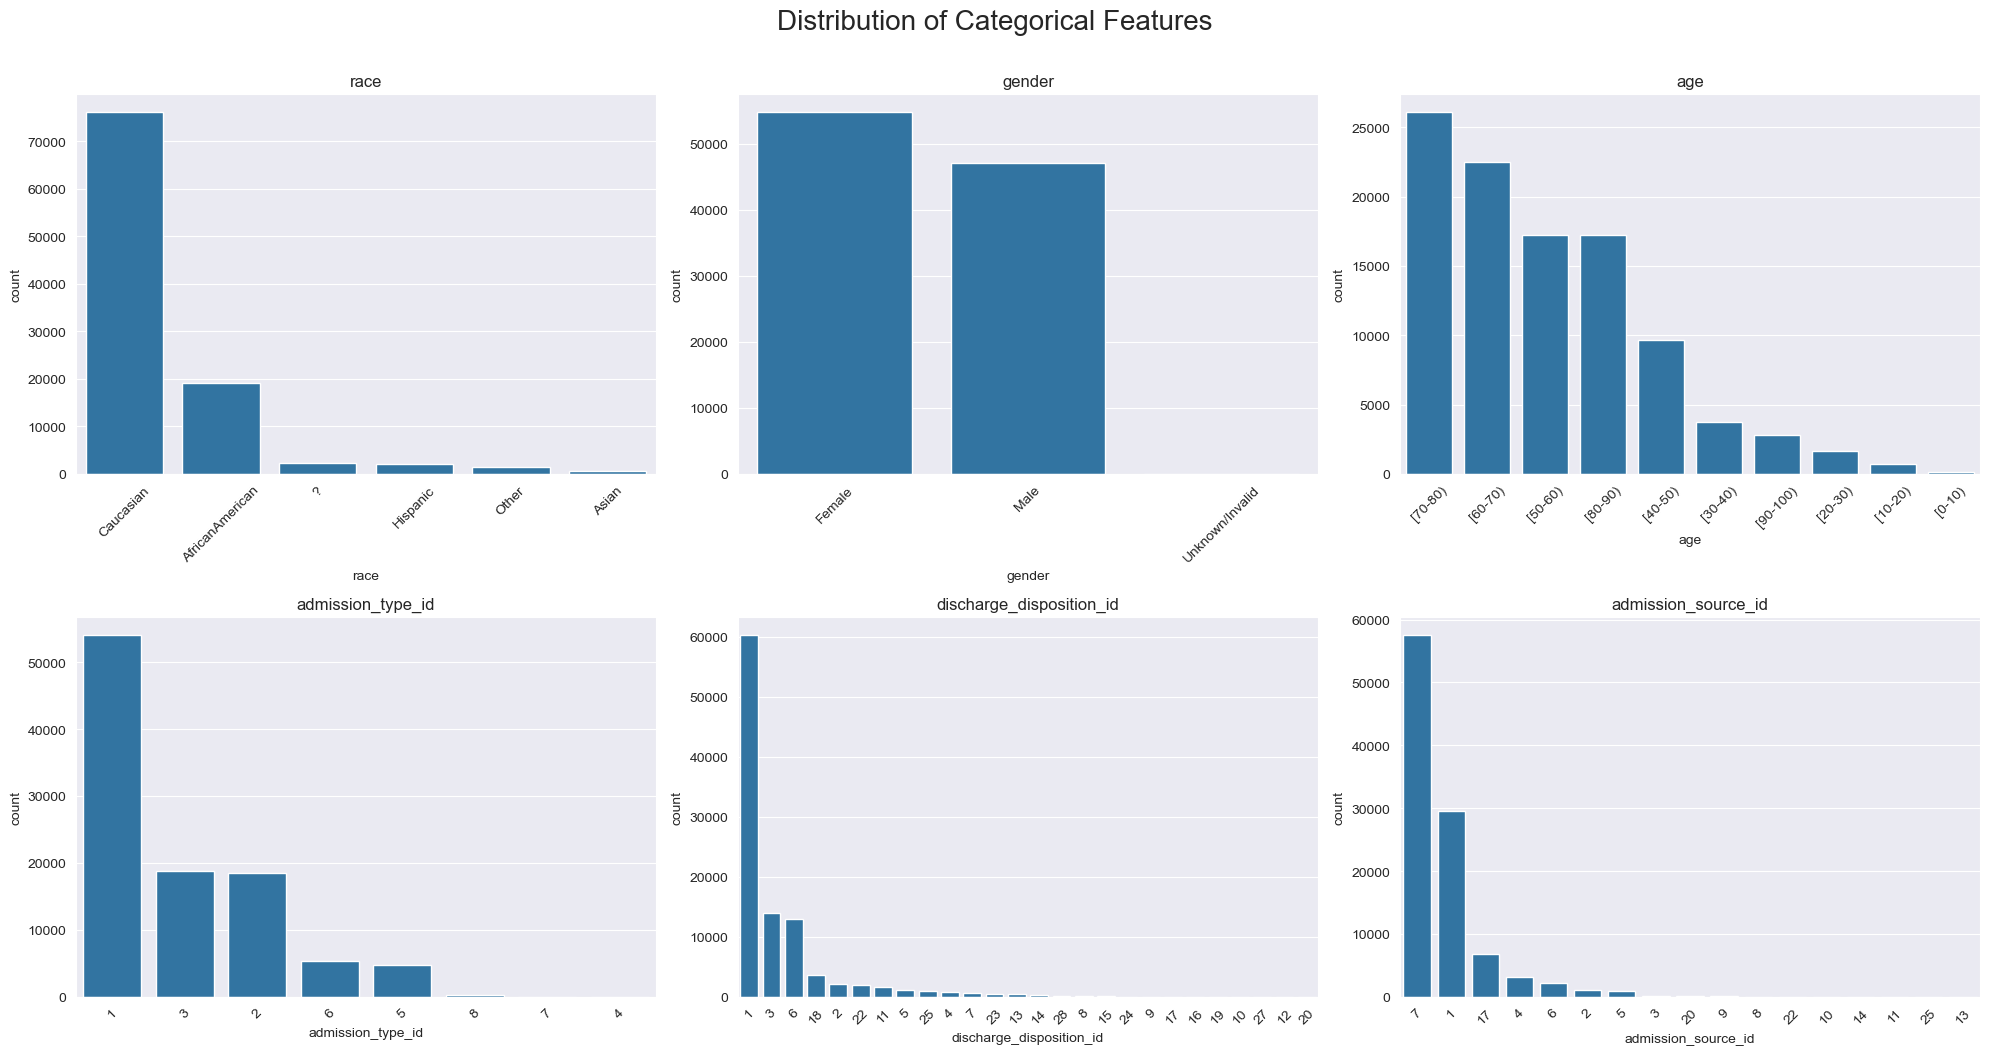

In [18]:
cat_cols = ['race', 'gender', 'age', 'admission_type_id',
            'discharge_disposition_id', 'admission_source_id']

plt.figure(figsize=(20, 10))  # adjust size based on data

for idx, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, idx)  # 2 rows, 3 columns, plot idx
    sns.countplot(x=col, data=df_eda, order=df_eda[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.suptitle('Distribution of Categorical Features', fontsize=20, y=1.05)
plt.show()

Check number of unique values a column has.

In [19]:
df_column_counts = df_eda.apply(lambda col: len(col.unique()))
df_column_counts

encounter_id                101766
patient_nbr                  71518
race                             6
gender                           3
age                             10
weight                          10
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
payer_code                      18
medical_specialty               73
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         717
diag_2                         749
diag_3                         790
number_diagnoses                16
max_glu_serum                    4
A1Cresult                        4
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride         

Since columns with only one unique value doesn't contribute much, we can drop those columns entirely

In [20]:
columns_with_one_unique_value = df_column_counts[
    df_column_counts == 1]  #Printing columns that have only one unique value
print(columns_with_one_unique_value.index)
df_eda = df_eda.drop(columns=columns_with_one_unique_value.index)
df_eda

Index(['examide', 'citoglipton'], dtype='object')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,label
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,Down,No,No,No,No,No,Ch,Yes,>30,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,Steady,No,No,No,No,No,No,Yes,NO,0
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,Down,No,No,No,No,No,Ch,Yes,NO,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,Up,No,No,No,No,No,Ch,Yes,NO,0


The dataset has '?' in place of NULL values so we replace it with NULL values

In [21]:
# Replace '?' with np.nan
df_eda.replace('?', np.nan, inplace=True)

In [22]:
df_eda.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [23]:
# Drop irrelevant columns
df_eda.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

# Drop columns with too many missing values
df_eda.drop(['weight', 'payer_code', 'medical_specialty'], axis=1, inplace=True)

# Remove duplicates
df_eda.drop_duplicates(inplace=True)

# Handle Gender Invalid
df_eda = df_eda[df_eda['gender'] != 'Unknown/Invalid']

# Handle missing race
df_eda.loc[:, 'race'] = df_eda['race'].fillna(df_eda['race'].mode()[0])

# Drop rows with missing diag_1, diag_2, diag_3
df_eda = df_eda.dropna(subset=['diag_1', 'diag_2', 'diag_3'])

We only dropped columns : 'weight', 'payer_code', 'medical_specialty' and not 'max_glu_serum','A1Cresult' because the 'None' value in 'max_glu_serum','A1Cresult' columns doesn't mean that they are missing values.

In [24]:
df_eda.isnull().sum()

race                            0
gender                          0
age                             0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               94978
A1Cresult                   83642
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone 

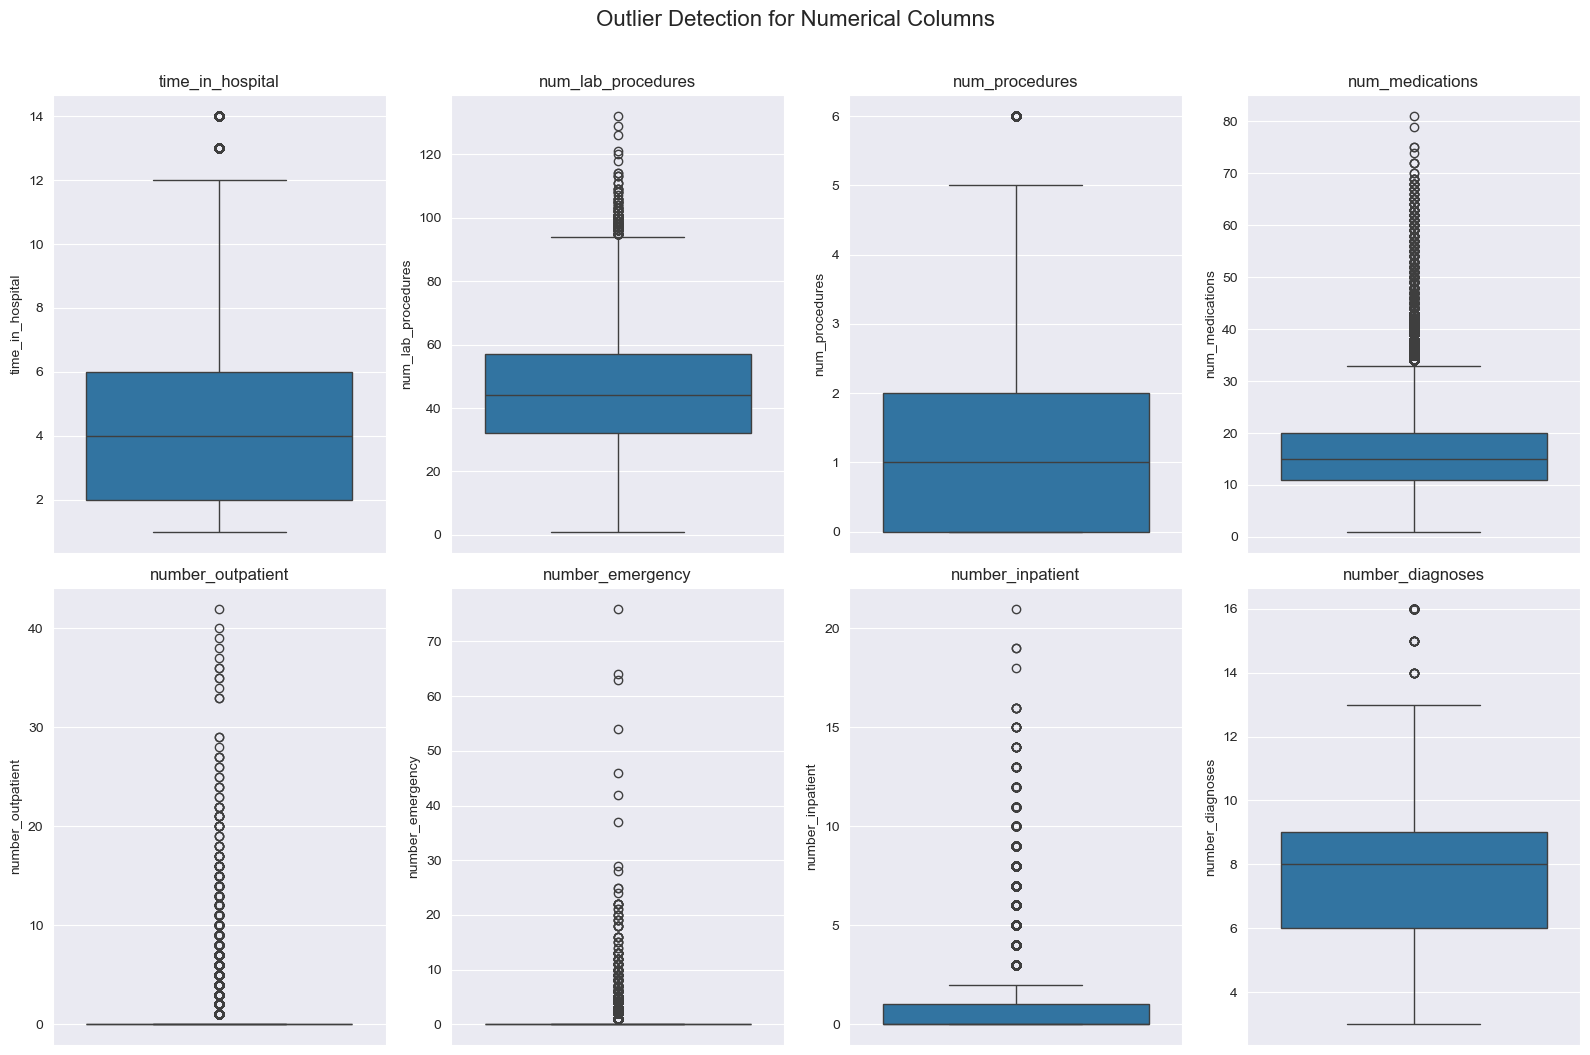

In [25]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']
plt.figure(figsize=(16, 10))  # width, height

for idx, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, idx)  # 2 rows, 4 columns, plot number idx
    sns.boxplot(y=df_eda[col])
    plt.title(col)

plt.tight_layout()
plt.suptitle('Outlier Detection for Numerical Columns', fontsize=16, y=1.05)
plt.show()

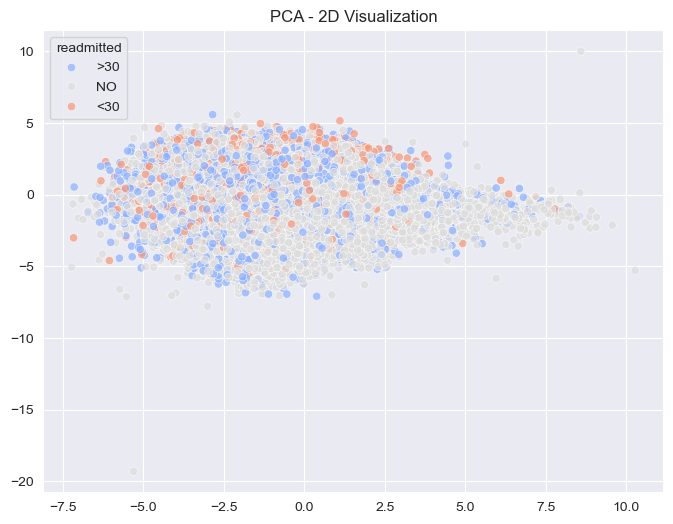

In [26]:
eda_df = df_eda.copy()

# Drop target variable for PCA
X = eda_df.drop('readmitted', axis=1)

# Convert categorical → numerical
X_encoded = pd.get_dummies(X, drop_first=True)

# Scaling is MUST before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df_eda['readmitted'], palette='coolwarm', alpha=0.7)
plt.title('PCA - 2D Visualization')
plt.show()

# Feature Engineering and Transformation



In [27]:
def barplot_per_classes(df_eda, attribute, groupby, title=None, ticks_rotation=0, topn=None, ax=None):
    uniq_values = df_eda[attribute].value_counts().head(topn).index
    df_eda = df_eda[df_eda[attribute].isin(uniq_values)]
    data = df_eda.groupby(groupby)[attribute].value_counts(normalize=True).rename('percentage').mul(100).reset_index()
    if ax is None:
        ax = plt.gca()
    sns.barplot(data=data, x=attribute, y='percentage', hue=groupby, ax=ax)
    ax.set_title(title)


def kdeplot_per_classes(df_eda, attribute, groupby, title=None, ticks_rotation=0, ax=None):
    if ax is None:
        ax = plt.gca()
    for x in df_eda[groupby].unique():
        sns.kdeplot(data=df_eda[df_eda[groupby] == x], x=attribute, label=x, fill=True, ax=ax)
    ax.set_title(title)
    ax.legend(title=groupby)


def boxplot_per_classes(df_eda, attribute, groupby, title=None, ticks_rotation=0, ax=None):
    if ax is None:
        ax = plt.gca()
    sns.boxplot(data=df_eda, x=groupby, y=attribute, ax=ax)
    ax.set_title(title)

In [28]:
df_eda.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'label'],
      dtype='object')

In [29]:
# Transform target variable
df_eda['readmitted'] = df_eda['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Map age ranges to midpoints
age_mapping = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
               '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
               '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
df_eda['age'] = df_eda['age'].map(age_mapping)

# Map categorical features to numerical values where applicable
categorical_mappings = {
    'gender': {'Female': 0, 'Male': 1},
    'change': {'No': 0, 'Ch': 1},
    'diabetesMed': {'No': 0, 'Yes': 1}
}

for col, mapping in categorical_mappings.items():
    df_eda[col] = df_eda[col].map(mapping)

# Add new column visits_sum i.e. the sum of number_emergency,number_outpatient,number_inpatient
df_eda['visits_sum'] = df_eda.apply(
    lambda x: x['number_emergency'] + x['number_outpatient'] + x['number_inpatient'], axis=1
)

all_medicaments = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Add new column number_medicaments_changes i.e. the number of changes provided through all medicaments
col_name = 'number_medicaments_changes'
df_eda[col_name] = 0

for medicament in all_medicaments:
    df_eda[col_name] = df_eda.apply(
        lambda x: x[col_name] + 1 if x[medicament] not in ['No', 'Steady'] else x[col_name], axis=1
    )

# Add new column number_medicaments i.e. the number of medicaments provided to patient
df_eda['number_medicaments'] = df_eda[all_medicaments].apply(
    lambda y: y.apply(lambda x: np.sum(0 if x == 'No' else 1)), axis=1
).apply(np.sum, axis=1)

In [30]:
diagnoses_cols = ['diag_1', 'diag_2', 'diag_3']
df_copy = df_eda.copy()
mapping = dict()
mapping['circulatory'] = list(range(390, 460)) + [785]
mapping['respiratory'] = list(range(460, 520)) + [786]
mapping['digestive'] = list(range(520, 580)) + [787]
mapping['diabetes'] = [250]
mapping['injury'] = list(range(800, 1000))
mapping['musculoskeletal'] = list(range(710, 740))
mapping['genitourinary'] = list(range(580, 630)) + [788]
mapping['neoplasm'] = list(range(140, 240))

all_codes = reduce(lambda x, y: x + mapping[y], mapping.keys(), [])
mapping['other'] = [x for x in range(1, 1000) if x not in all_codes]
mapping['other'] = mapping['other'] + list(string.ascii_uppercase)
for key in mapping.keys():
    mapping[key] = [str(x) for x in mapping[key]]


def map_code_to_diagnose(code, mapping):
    code = str(code)
    if not code:
        return None
    for diagnose in mapping.keys():
        if diagnose in ['diabetes', 'other']:
            if any([code.startswith(x) for x in mapping[diagnose]]):
                return diagnose
            else:
                continue
        if code in mapping[diagnose]:
            return diagnose


for column in diagnoses_cols:
    df_copy[f'{column}_category'] = df_copy[column].apply(lambda x: map_code_to_diagnose(x, mapping))
df_eda = df_copy.drop(diagnoses_cols, axis=1)

In [31]:
# Categorical one hot encoding
df_eda = pd.get_dummies(df_eda, columns=['race', 'metformin', 'repaglinide',
                                         'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
                                         'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
                                         'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
                                         'insulin', 'glyburide-metformin', 'glipizide-metformin',
                                         'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                                         'metformin-pioglitazone', 'diag_1_category', 'diag_2_category',
                                         'diag_3_category', 'max_glu_serum', 'A1Cresult'], drop_first=True)

In [32]:
for i in range(len(df_eda.columns)):
    print(df_eda.columns[i])

gender
age
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
number_diagnoses
change
diabetesMed
readmitted
label
visits_sum
number_medicaments_changes
number_medicaments
race_Asian
race_Caucasian
race_Hispanic
race_Other
metformin_No
metformin_Steady
metformin_Up
repaglinide_No
repaglinide_Steady
repaglinide_Up
nateglinide_No
nateglinide_Steady
nateglinide_Up
chlorpropamide_No
chlorpropamide_Steady
chlorpropamide_Up
glimepiride_No
glimepiride_Steady
glimepiride_Up
acetohexamide_Steady
glipizide_No
glipizide_Steady
glipizide_Up
glyburide_No
glyburide_Steady
glyburide_Up
tolbutamide_Steady
pioglitazone_No
pioglitazone_Steady
pioglitazone_Up
rosiglitazone_No
rosiglitazone_Steady
rosiglitazone_Up
acarbose_No
acarbose_Steady
acarbose_Up
miglitol_No
miglitol_Steady
miglitol_Up
troglitazone_Steady
tolazamide_Steady
tolazamide_Up
insulin_No
insulin_Steady
insulin

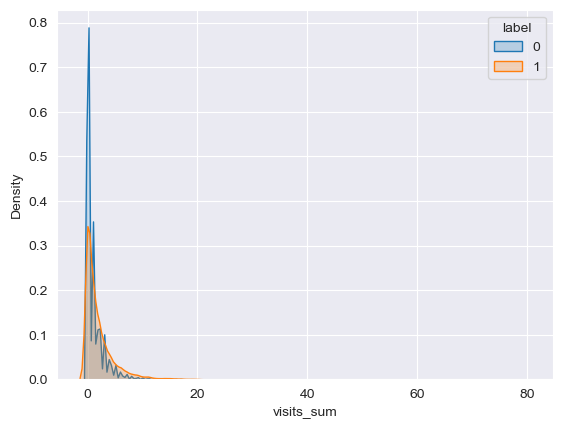

In [33]:
kdeplot_per_classes(df_eda, 'visits_sum', 'label')

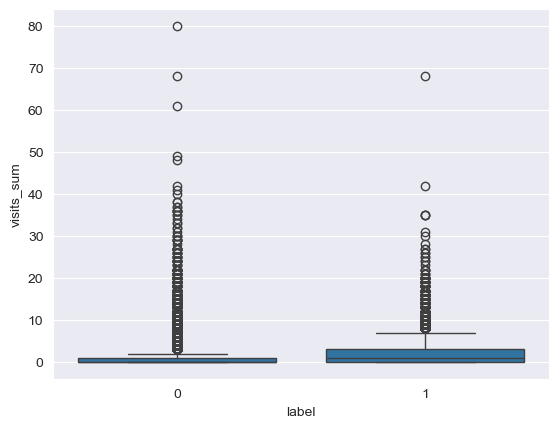

In [34]:
boxplot_per_classes(df_eda, 'visits_sum', 'label')

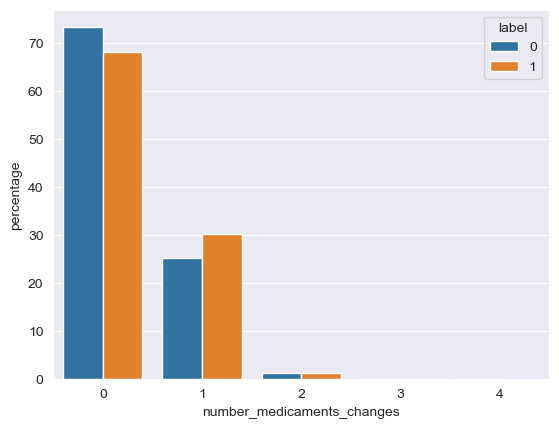

In [35]:
barplot_per_classes(df_eda, 'number_medicaments_changes', 'label')

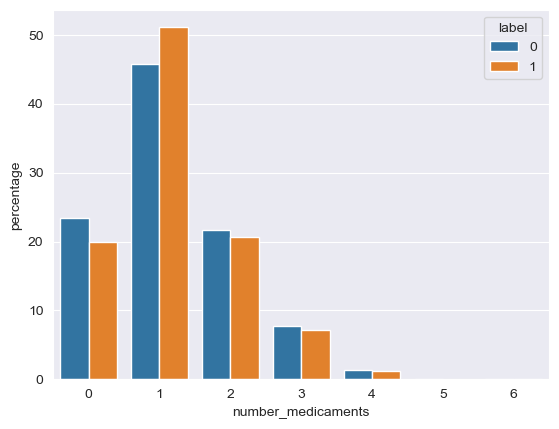

In [36]:
barplot_per_classes(df_eda, 'number_medicaments', 'label')

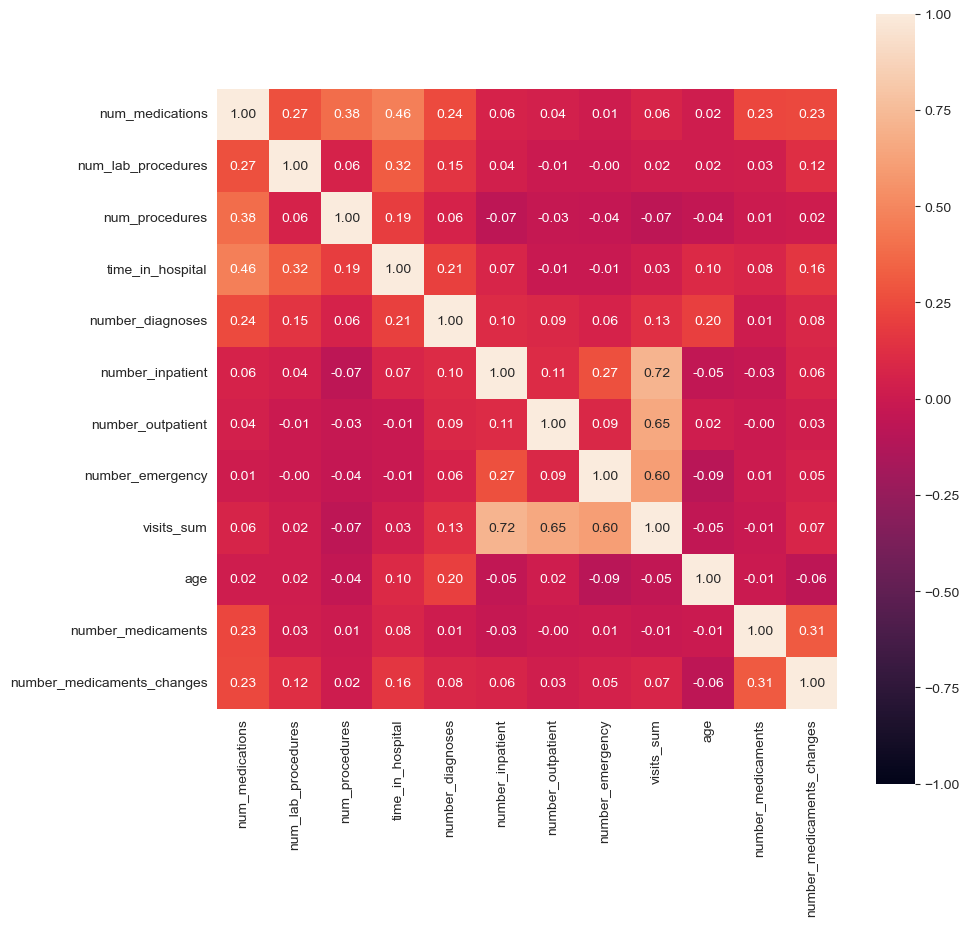

In [37]:
columns = [
    'num_medications', 'num_lab_procedures', 'num_procedures', 'time_in_hospital',
    'number_diagnoses', 'number_inpatient', 'number_outpatient', 'number_emergency',
    'visits_sum', 'age', 'number_medicaments', 'number_medicaments_changes'
]
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df_eda[columns].corr(), annot=True, fmt=".2f", vmin=-1.0, vmax=1.0, square=True);

# Train-test Split

In [38]:
X = df_eda.drop(columns=['readmitted', 'label'], axis=1)
y = df_eda['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.columns

Index(['gender', 'age', 'admission_type_id', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'change',
       'diabetesMed', 'visits_sum', 'number_medicaments_changes',
       'number_medicaments', 'race_Asian', 'race_Caucasian', 'race_Hispanic',
       'race_Other', 'metformin_No', 'metformin_Steady', 'metformin_Up',
       'repaglinide_No', 'repaglinide_Steady', 'repaglinide_Up',
       'nateglinide_No', 'nateglinide_Steady', 'nateglinide_Up',
       'chlorpropamide_No', 'chlorpropamide_Steady', 'chlorpropamide_Up',
       'glimepiride_No', 'glimepiride_Steady', 'glimepiride_Up',
       'acetohexamide_Steady', 'glipizide_No', 'glipizide_Steady',
       'glipizide_Up', 'glyburide_No', 'glyburide_Steady', 'glyburide_Up',
       'tolbutamide_Steady', 'pioglitazone_No', 'pioglitazone_Steady',
       'piogli

In [39]:
scaler = MinMaxScaler()
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'age']

df_eda[num_cols] = scaler.fit_transform(df_eda[num_cols])

In [40]:
visits_cols = ['number_emergency', 'number_outpatient', 'number_inpatient']
medicaments_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]


In [41]:
X_train.shape, X_test.shape

((80192, 98), (20049, 98))

# Model Selection

### Data Balancing

Since the target classes are heavily imbalanced, we are going to use two techniques for balancing the data.
- Undersampling by random
- Oversampling by SMOTE

In [42]:
# Undersampling by random
rus = RandomUnderSampler(random_state=3)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)
len(X_train_undersampled), len(y_train_undersampled)

(18074, 18074)

In [43]:
# Oversampling by SMOTE
smote = SMOTE(random_state=42)
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)
len(X_train_oversampled), len(y_train_oversampled)

(142310, 142310)

In [44]:
def evaluate_model(model, X, y, figsize=(12, 5)):
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # --- Subplot 1: Confusion Matrix ---
    ConfusionMatrixDisplay.from_estimator(model, X, y, ax=ax1, cmap='Blues')
    ax1.set_title('Confusion Matrix')

    # --- Subplot 2: ROC Curve ---
    y_pred_prob = model.predict_proba(X)[:, 1]
    roc_auc(y_pred_prob, y, ax=ax2)

    plt.tight_layout()
    plt.show()

    # Print classification report and AUC score
    y_pred = model.predict(X)
    print(classification_report(y, y_pred))
    print(f'ROC AUC score: {round(roc_auc_score(y, y_pred_prob), 3)}')


def roc_auc(y_pred_prob, y_true, label="Model", ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    auc_value = auc(fpr, tpr)

    if ax is None:
        fig, ax = plt.subplots()

    # Plot ROC curve
    ax.scatter(x=fpr, y=tpr, color='navy')
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'{label} (AUC = {auc_value:.3f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc="lower right")

    return auc_value


def compare_models(models, names, x, y):
    max_len = np.max([len(x) for x in names])
    print("      ".ljust(max_len) + "     Accuracy   F1 (micro)  F1 (macro)"
                                    "  Precision   Recall    AUC ROC")
    for i, model in enumerate(models):
        y_pred = model.predict(x)
        y_pred_prob = model.predict_proba(x)[:, 1]
        print(f"{names[i]}" + "".ljust(max_len - len(names[i])) + "   "
                                                                  f"|   {accuracy_score(y, y_pred):.2f}   "
                                                                  f"|   {f1_score(y, y_pred, average='micro'):.2f}    "
                                                                  f"|   {f1_score(y, y_pred, average='macro'):.2f}    "
                                                                  f"|   {precision_score(y, y_pred):.2f}    "
                                                                  f"|   {recall_score(y, y_pred):.2f}   "
                                                                  f"|   {roc_auc_score(y, y_pred_prob):.2f}   |")

### Linear Regression

C:\Users\Z\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


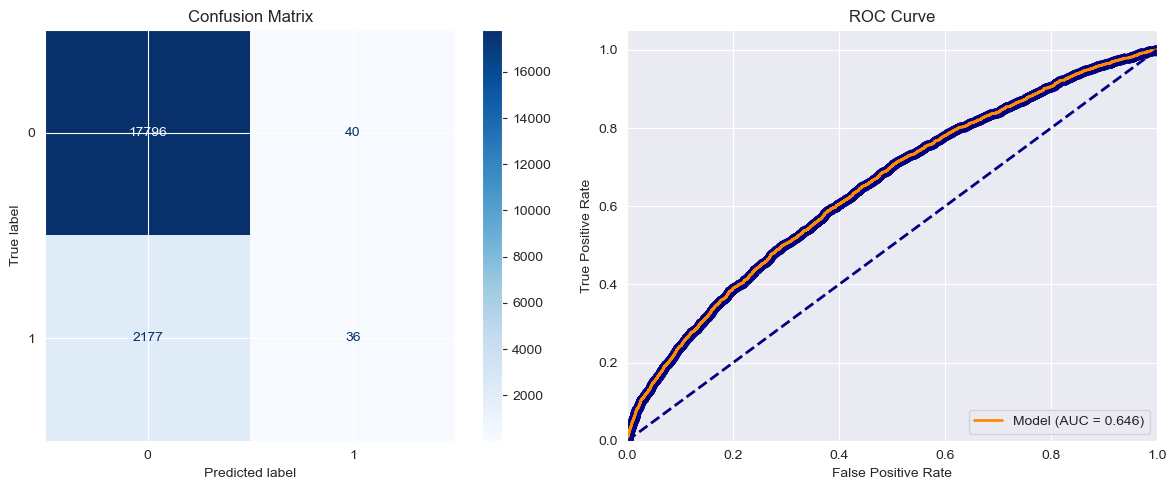

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17836
           1       0.47      0.02      0.03      2213

    accuracy                           0.89     20049
   macro avg       0.68      0.51      0.49     20049
weighted avg       0.84      0.89      0.84     20049

ROC AUC score: 0.646


In [45]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
evaluate_model(lr, X_test, y_test)

C:\Users\Z\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


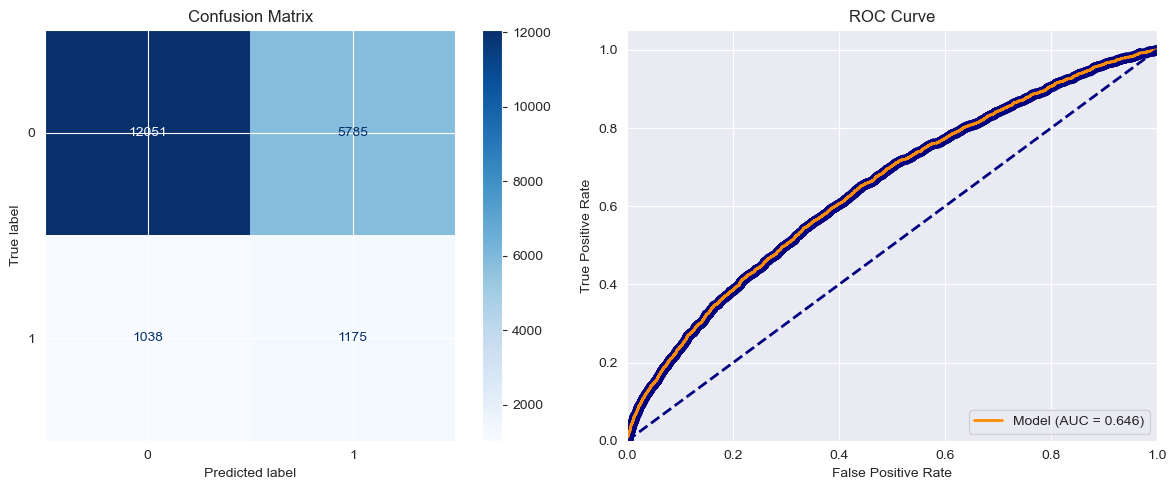

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17836
           1       0.17      0.53      0.26      2213

    accuracy                           0.66     20049
   macro avg       0.54      0.60      0.52     20049
weighted avg       0.84      0.66      0.72     20049

ROC AUC score: 0.646


In [46]:
lr_u = LogisticRegression(max_iter=1000)
lr_u.fit(X_train_undersampled, y_train_undersampled)
pred_lr = lr_u.predict(X_test)
evaluate_model(lr_u, X_test, y_test)

C:\Users\Z\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


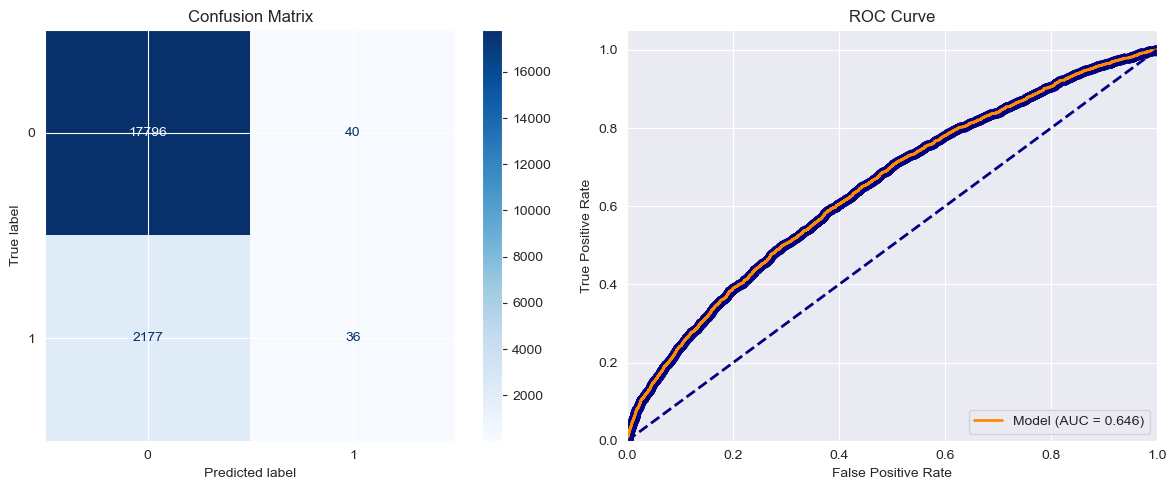

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17836
           1       0.47      0.02      0.03      2213

    accuracy                           0.89     20049
   macro avg       0.68      0.51      0.49     20049
weighted avg       0.84      0.89      0.84     20049

ROC AUC score: 0.646


In [47]:
lr_o = LogisticRegression(max_iter=1000)
lr_o.fit(X_train_oversampled, y_train_oversampled)
pred_lr = lr_o.predict(X_test)
evaluate_model(lr, X_test, y_test)

In [48]:
compare_models([lr, lr_u, lr_o], ['LR', 'LR undersampled', 'LR oversampled'], X_test, y_test)

                    Accuracy   F1 (micro)  F1 (macro)  Precision   Recall    AUC ROC
LR                |   0.89   |   0.89    |   0.49    |   0.47    |   0.02   |   0.65   |
LR undersampled   |   0.66   |   0.66    |   0.52    |   0.17    |   0.53   |   0.65   |
LR oversampled    |   0.87   |   0.87    |   0.50    |   0.17    |   0.05   |   0.58   |


### Cat Boost

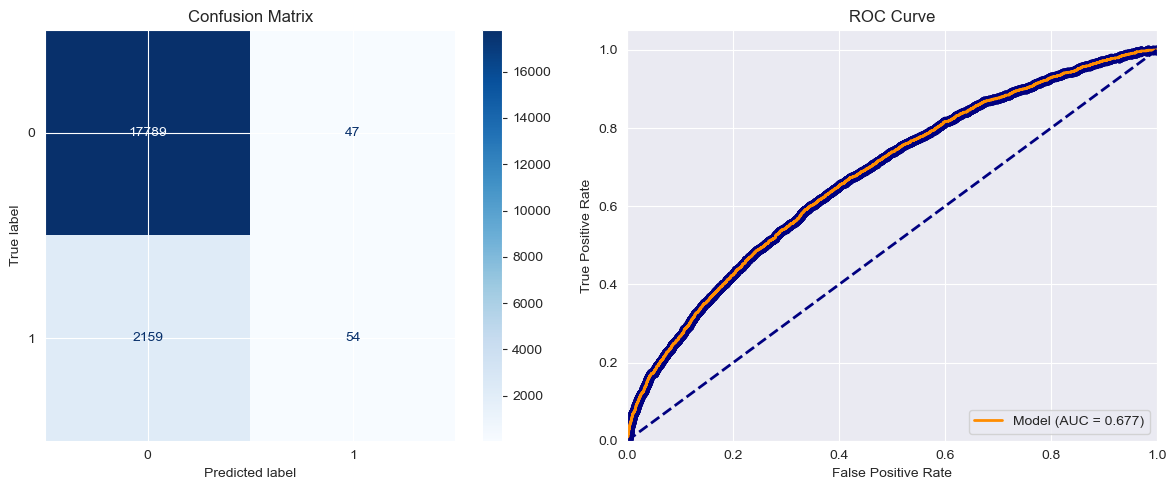

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17836
           1       0.53      0.02      0.05      2213

    accuracy                           0.89     20049
   macro avg       0.71      0.51      0.49     20049
weighted avg       0.85      0.89      0.84     20049

ROC AUC score: 0.677


In [49]:
cat = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0)
cat.fit(X_train, y_train)
pred_cat = cat.predict(X_test)
evaluate_model(cat, X_test, y_test)

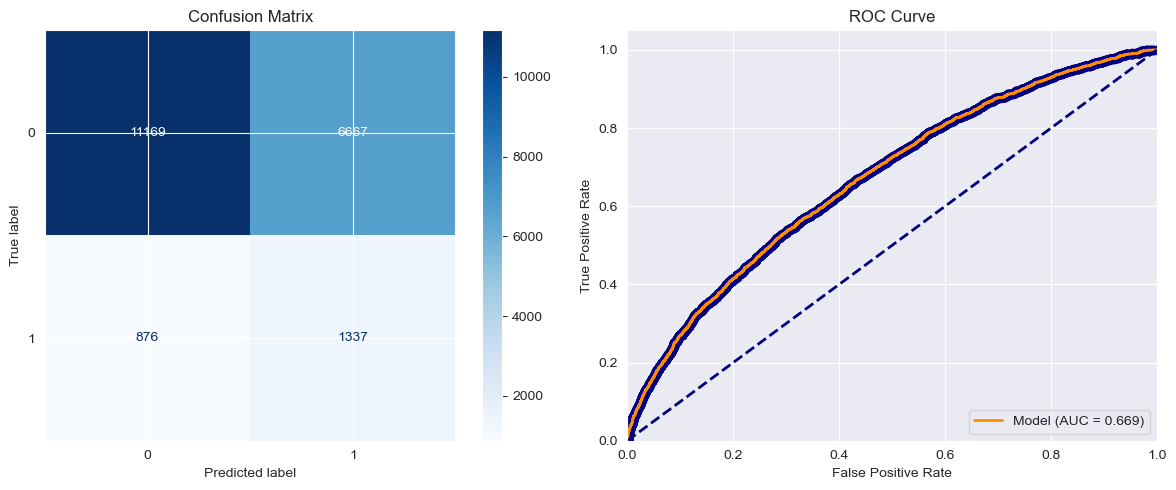

              precision    recall  f1-score   support

           0       0.93      0.63      0.75     17836
           1       0.17      0.60      0.26      2213

    accuracy                           0.62     20049
   macro avg       0.55      0.62      0.50     20049
weighted avg       0.84      0.62      0.69     20049

ROC AUC score: 0.669


In [50]:
cat_u = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0)
cat_u.fit(X_train_undersampled, y_train_undersampled)
pred_cat = cat_u.predict(X_test)
evaluate_model(cat_u, X_test, y_test)

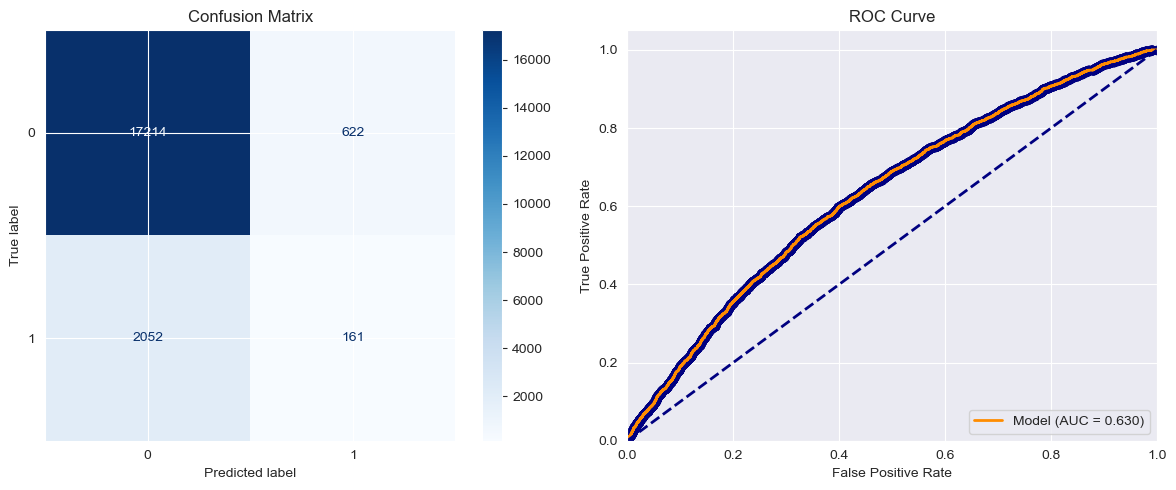

              precision    recall  f1-score   support

           0       0.89      0.97      0.93     17836
           1       0.21      0.07      0.11      2213

    accuracy                           0.87     20049
   macro avg       0.55      0.52      0.52     20049
weighted avg       0.82      0.87      0.84     20049

ROC AUC score: 0.63


In [51]:
cat_o = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0)
cat_o.fit(X_train_oversampled, y_train_oversampled)
pred_cat = cat_o.predict(X_test)
evaluate_model(cat_o, X_test, y_test)

In [52]:
compare_models([cat, cat_u, cat_o], ['Cat Boost', 'Cat Boost undersampled', 'Cat Boost oversampled'], X_test, y_test)

                           Accuracy   F1 (micro)  F1 (macro)  Precision   Recall    AUC ROC
Cat Boost                |   0.89   |   0.89    |   0.49    |   0.53    |   0.02   |   0.68   |
Cat Boost undersampled   |   0.62   |   0.62    |   0.50    |   0.17    |   0.60   |   0.67   |
Cat Boost oversampled    |   0.87   |   0.87    |   0.52    |   0.21    |   0.07   |   0.63   |


### K - Nearest Neighbour

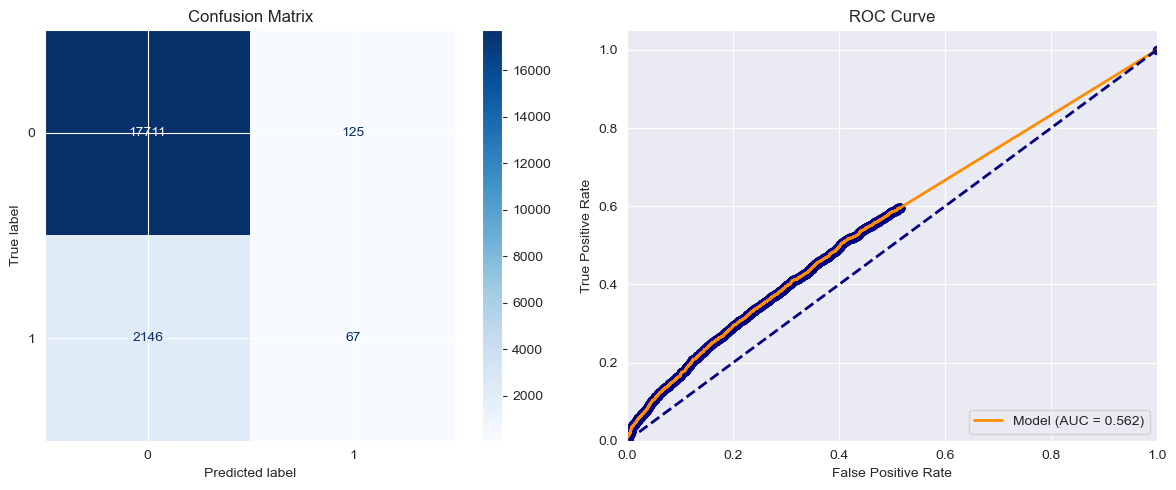

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     17836
           1       0.35      0.03      0.06      2213

    accuracy                           0.89     20049
   macro avg       0.62      0.51      0.50     20049
weighted avg       0.83      0.89      0.84     20049

ROC AUC score: 0.562


In [53]:
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
evaluate_model(knn, X_test, y_test)

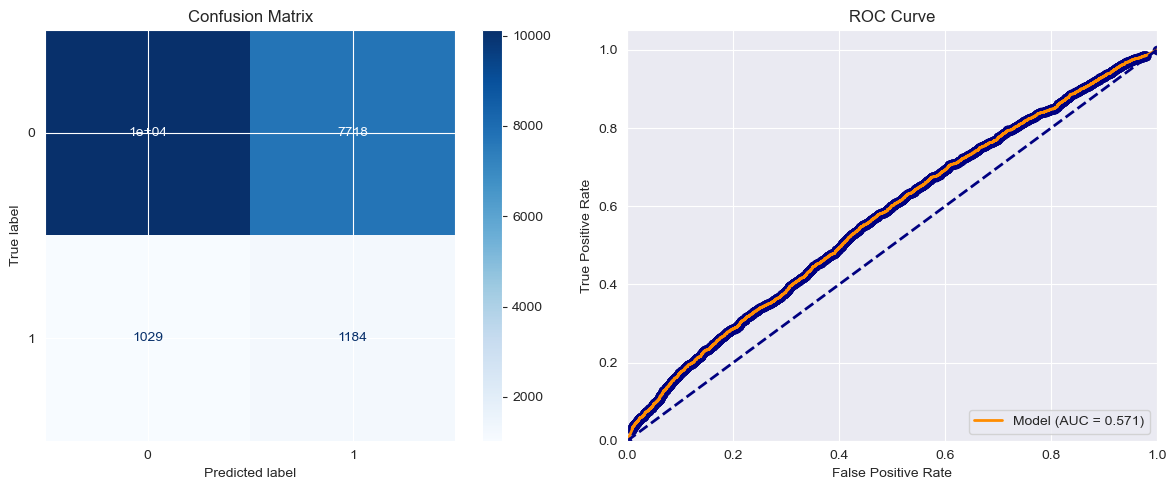

              precision    recall  f1-score   support

           0       0.91      0.57      0.70     17836
           1       0.13      0.54      0.21      2213

    accuracy                           0.56     20049
   macro avg       0.52      0.55      0.46     20049
weighted avg       0.82      0.56      0.64     20049

ROC AUC score: 0.571


In [54]:
knn_u = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_u.fit(X_train_undersampled, y_train_undersampled)
pred_knn = knn_u.predict(X_test)
evaluate_model(knn_u, X_test, y_test)

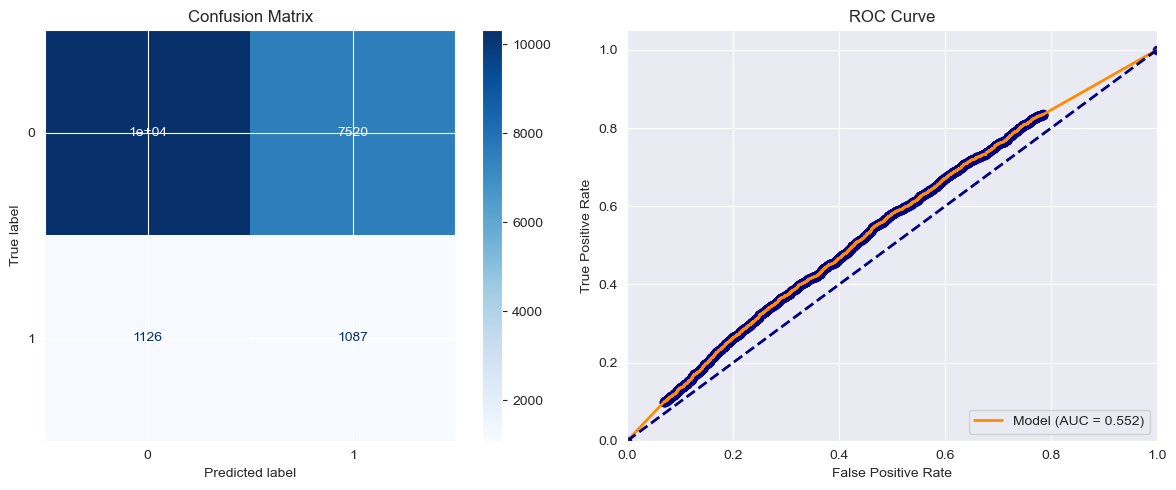

              precision    recall  f1-score   support

           0       0.90      0.58      0.70     17836
           1       0.13      0.49      0.20      2213

    accuracy                           0.57     20049
   macro avg       0.51      0.53      0.45     20049
weighted avg       0.82      0.57      0.65     20049

ROC AUC score: 0.552


In [55]:
knn_o = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_o.fit(X_train_oversampled, y_train_oversampled)
pred_knn = knn_o.predict(X_test)
evaluate_model(knn_o, X_test, y_test)

In [56]:
compare_models([knn, knn_u, knn_o], ['KNN', 'KNN undersampled', 'KNN oversampled'], X_test, y_test)

                     Accuracy   F1 (micro)  F1 (macro)  Precision   Recall    AUC ROC
KNN                |   0.89   |   0.89    |   0.50    |   0.35    |   0.03   |   0.56   |
KNN undersampled   |   0.56   |   0.56    |   0.46    |   0.13    |   0.54   |   0.57   |
KNN oversampled    |   0.57   |   0.57    |   0.45    |   0.13    |   0.49   |   0.55   |


###  Gaussian Naive Bayes

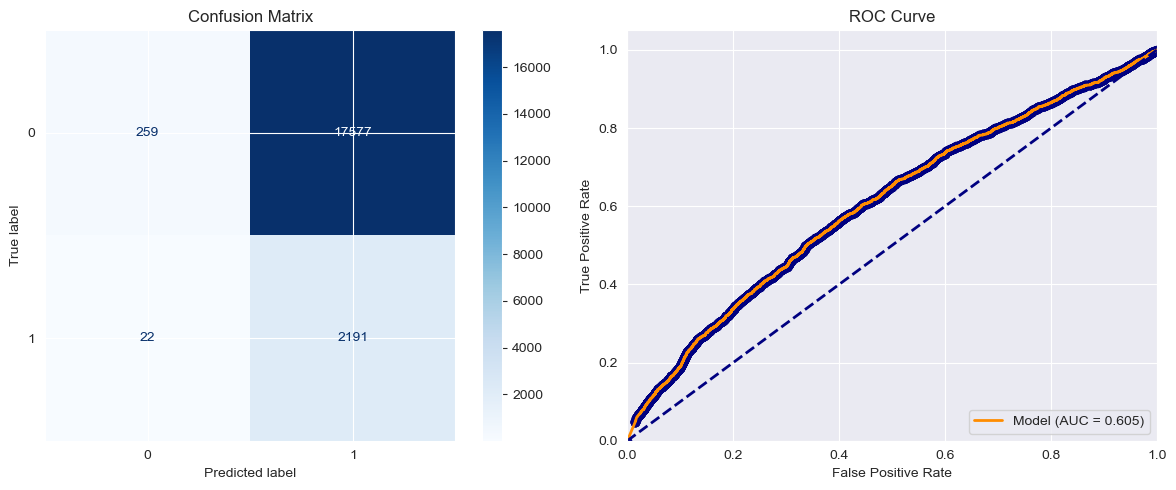

              precision    recall  f1-score   support

           0       0.92      0.01      0.03     17836
           1       0.11      0.99      0.20      2213

    accuracy                           0.12     20049
   macro avg       0.52      0.50      0.11     20049
weighted avg       0.83      0.12      0.05     20049

ROC AUC score: 0.605


In [57]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
evaluate_model(nb, X_test, y_test)

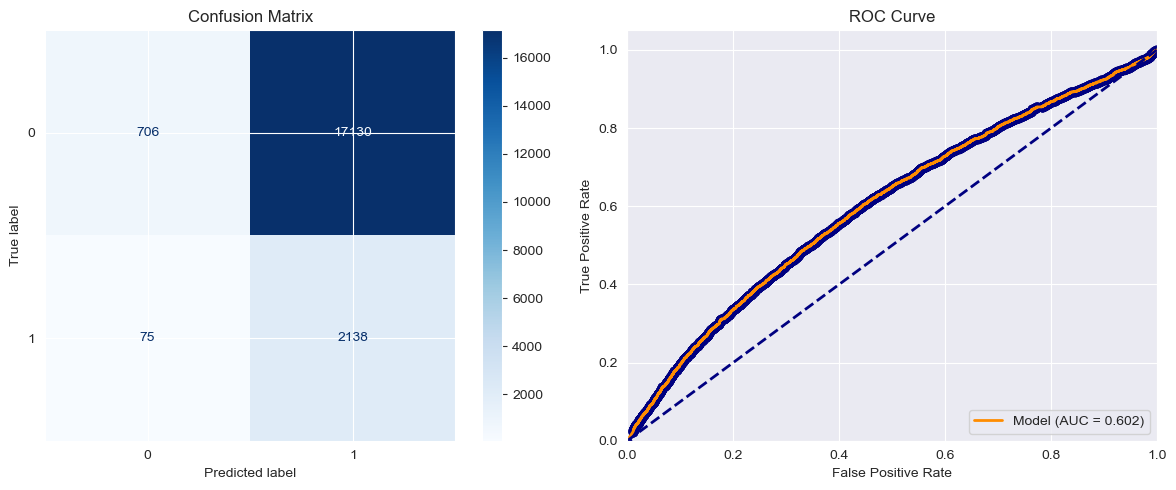

              precision    recall  f1-score   support

           0       0.90      0.04      0.08     17836
           1       0.11      0.97      0.20      2213

    accuracy                           0.14     20049
   macro avg       0.51      0.50      0.14     20049
weighted avg       0.82      0.14      0.09     20049

ROC AUC score: 0.602


In [58]:
nb_u = GaussianNB()
nb_u.fit(X_train_undersampled, y_train_undersampled)
pred_nb = nb_u.predict(X_test)
evaluate_model(nb_u, X_test, y_test)

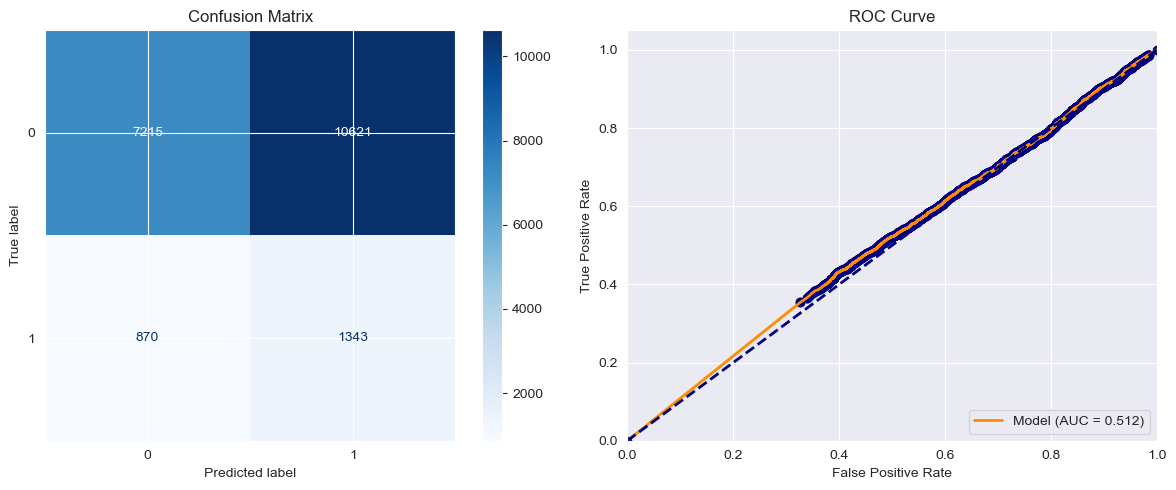

              precision    recall  f1-score   support

           0       0.89      0.40      0.56     17836
           1       0.11      0.61      0.19      2213

    accuracy                           0.43     20049
   macro avg       0.50      0.51      0.37     20049
weighted avg       0.81      0.43      0.52     20049

ROC AUC score: 0.512


In [59]:
nb_o = GaussianNB()
nb_o.fit(X_train_oversampled, y_train_oversampled)
pred_nb = nb_o.predict(X_test)
evaluate_model(nb_o, X_test, y_test)

In [60]:
compare_models([nb, nb_u, nb_o], ['NB', 'NB undersampled', 'NB oversampled'], X_test, y_test)

                    Accuracy   F1 (micro)  F1 (macro)  Precision   Recall    AUC ROC
NB                |   0.12   |   0.12    |   0.11    |   0.11    |   0.99   |   0.60   |
NB undersampled   |   0.14   |   0.14    |   0.14    |   0.11    |   0.97   |   0.60   |
NB oversampled    |   0.43   |   0.43    |   0.37    |   0.11    |   0.61   |   0.51   |


In [61]:
compare_models(
    [lr, lr_u, lr_o, cat, cat_u, cat_o, knn, knn_u, knn_o, nb, nb_u, nb_o],
    ['LR', 'LR undersampled', 'LR oversampled',
     'Cat Boost', 'Cat Boost undersampled', 'Cat Boost oversampled',
     'KNN', 'KNN undersampled', 'KNN oversampled',
     'NB', 'NB undersampled', 'NB oversampled'],
    X_test, y_test
)

                           Accuracy   F1 (micro)  F1 (macro)  Precision   Recall    AUC ROC
LR                       |   0.89   |   0.89    |   0.49    |   0.47    |   0.02   |   0.65   |
LR undersampled          |   0.66   |   0.66    |   0.52    |   0.17    |   0.53   |   0.65   |
LR oversampled           |   0.87   |   0.87    |   0.50    |   0.17    |   0.05   |   0.58   |
Cat Boost                |   0.89   |   0.89    |   0.49    |   0.53    |   0.02   |   0.68   |
Cat Boost undersampled   |   0.62   |   0.62    |   0.50    |   0.17    |   0.60   |   0.67   |
Cat Boost oversampled    |   0.87   |   0.87    |   0.52    |   0.21    |   0.07   |   0.63   |
KNN                      |   0.89   |   0.89    |   0.50    |   0.35    |   0.03   |   0.56   |
KNN undersampled         |   0.56   |   0.56    |   0.46    |   0.13    |   0.54   |   0.57   |
KNN oversampled          |   0.57   |   0.57    |   0.45    |   0.13    |   0.49   |   0.55   |
NB                       |   0.12   |   0.12

# Evaluation

#### Data Visualization

#### 2D Visualization using T-SNE

CPU times: total: 1min 23s
Wall time: 4min 3s


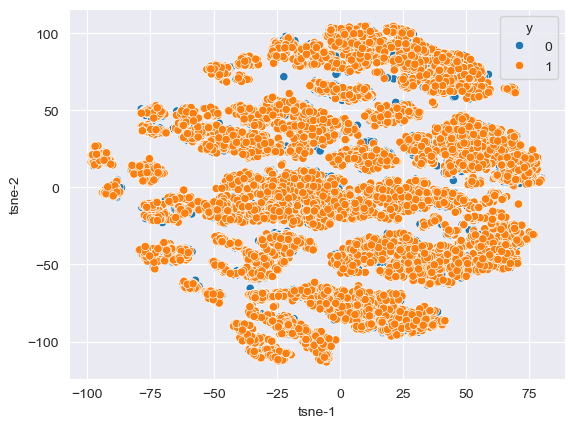

In [62]:
%%time
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(X_train_undersampled)
df_tsne = pd.DataFrame({
    'tsne-1': tsne_result[:, 0],
    'tsne-2': tsne_result[:, 1],
    'y': list(y_train_undersampled)
})

sns.scatterplot(x='tsne-1', y='tsne-2', hue='y', data=df_tsne, legend='full');

#### 3D-Visualization using T-SNE

In [63]:
%%time
tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(X_train_undersampled)

CPU times: total: 5min 30s
Wall time: 16min 56s


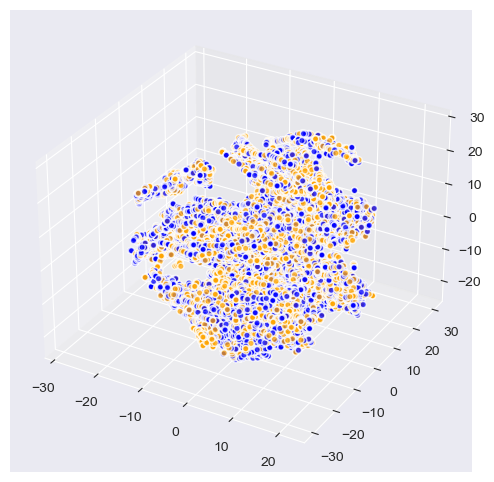

In [64]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    tsne_result[:, 2],
    c=['orange' if x == 1 else 'blue' for x in list(y_train_undersampled)],
    alpha=0.75,
    edgecolors='w'
)
plt.show()

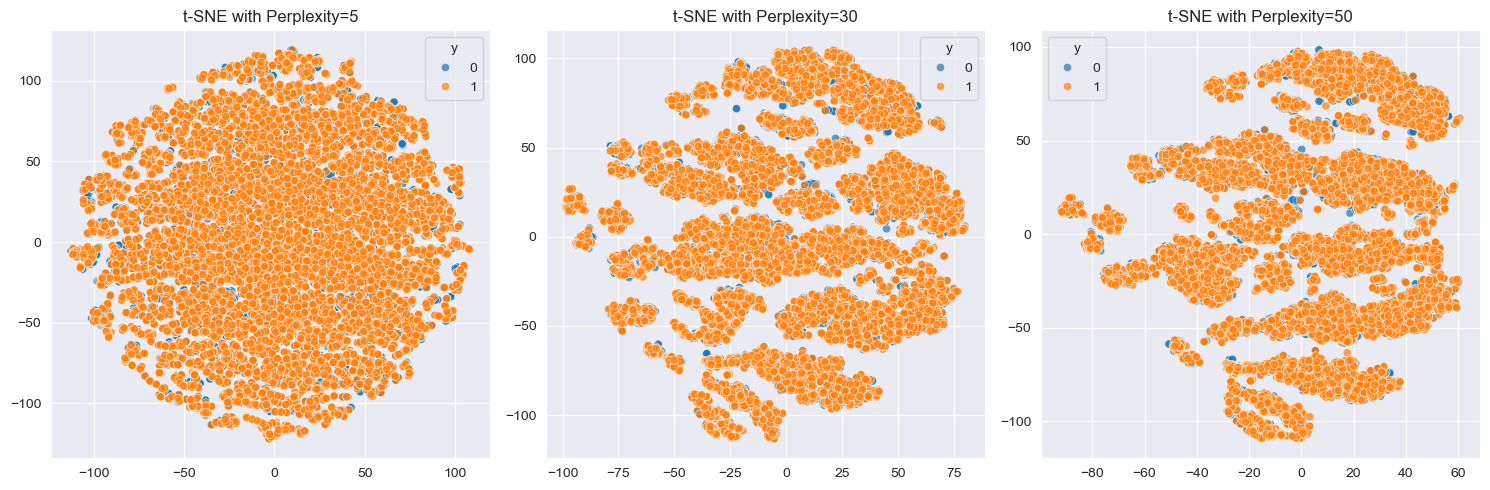

In [65]:
perplexities = [5, 30, 50]

plt.figure(figsize=(15, 5))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    tsne_result = tsne.fit_transform(X_train_undersampled)

    df_tsne = pd.DataFrame({
        'tsne-1': tsne_result[:, 0],
        'tsne-2': tsne_result[:, 1],
        'y': y_train_undersampled
    })

    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x='tsne-1', y='tsne-2', hue='y', data=df_tsne, legend='full', alpha=0.7)
    plt.title(f't-SNE with Perplexity={p}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

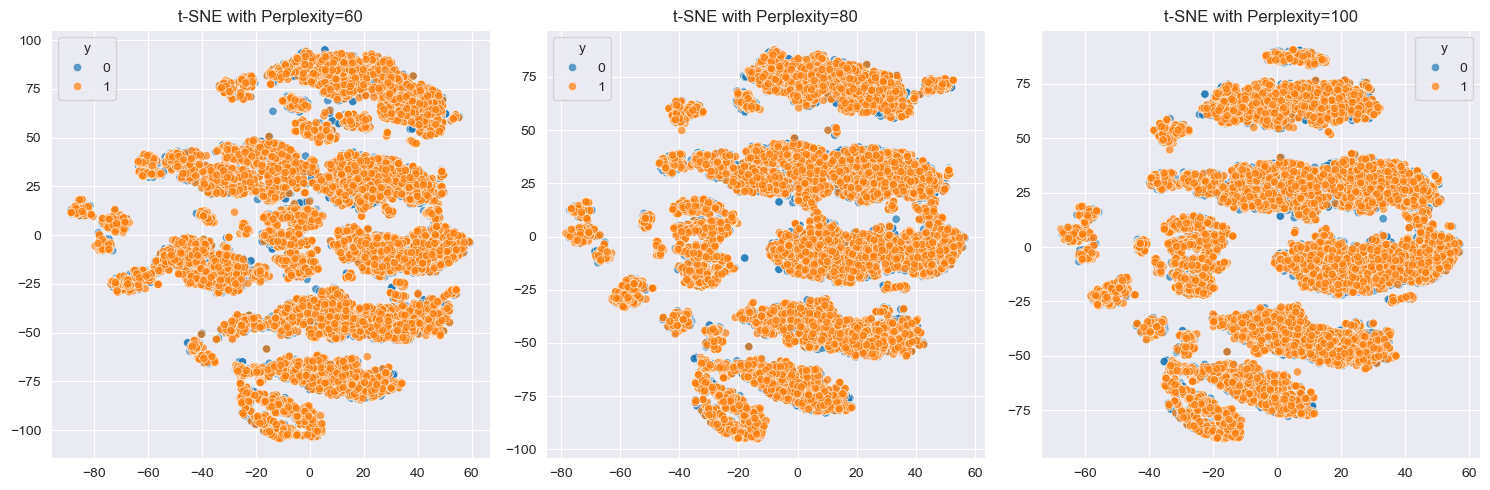

In [66]:
perplexities = [60,80,100]

plt.figure(figsize=(15, 5))

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    tsne_result = tsne.fit_transform(X_train_undersampled)

    df_tsne = pd.DataFrame({
        'tsne-1': tsne_result[:, 0],
        'tsne-2': tsne_result[:, 1],
        'y': y_train_undersampled
    })

    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x='tsne-1', y='tsne-2', hue='y', data=df_tsne, legend='full', alpha=0.7)
    plt.title(f't-SNE with Perplexity={p}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [67]:
def get_feature_importance(model, model_name: str, X_train, y_train, feature_names=None):
    if feature_names is None and isinstance(X_train, pd.DataFrame):
        feature_names = X_train.columns
    elif feature_names is None:
        feature_names = [f"Feature {i}" for i in range(X_train.shape[1])]

    if model_name.lower() == 'logistic':
        importance = model.coef_[0]
        return pd.DataFrame({'Feature': feature_names, 'Importance': importance}) \
                 .sort_values(by='Importance', key=abs, ascending=False)

    elif model_name.lower() == 'catboost':
        importances = model.get_feature_importance()
        return pd.DataFrame({'Feature': feature_names, 'Importance': importances}) \
                 .sort_values(by='Importance', ascending=False)

    elif model_name.lower() in ['knn', 'naive_bayes', 'nb']:
        result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1)
        return pd.DataFrame({'Feature': feature_names, 'Importance': result.importances_mean}) \
                 .sort_values(by='Importance', ascending=False)

    else:
        raise ValueError("Model name not recognized. Use: 'logistic', 'catboost', 'knn', or 'naive_bayes'")


In [73]:
X_sets = {
    'original': X_train,
    'undersampled': X_train_undersampled,
    'oversampled': X_train_oversampled
}

y_sets = {
    'original': y_train,
    'undersampled': y_train_undersampled,
    'oversampled': y_train_oversampled
}

model_list = {
    'lr_original': ('logistic', lr, 'original'),
    'lr_undersampled': ('logistic', lr_u, 'undersampled'),
    'lr_oversampled': ('logistic', lr_o, 'oversampled'),

    'cat_original': ('catboost', cat, 'original'),
    'cat_undersampled': ('catboost', cat_u, 'undersampled'),
    'cat_oversampled': ('catboost', cat_o, 'oversampled')

    # 'knn_original': ('knn', knn, 'original'),
    # 'knn_undersampled': ('knn', knn_u, 'undersampled'),
    # 'knn_oversampled': ('knn', knn_o, 'oversampled'),
    #
    # 'nb_original': ('naive_bayes', nb, 'original'),
    # 'nb_undersampled': ('naive_bayes', nb_u, 'undersampled'),
    # 'nb_oversampled': ('naive_bayes', nb_o, 'oversampled')
}

# Run feature importance and store results
importance_results = {}

for name, (model_type, model, sample_type) in model_list.items():
    X = X_sets[sample_type]
    y = y_sets[sample_type]
    importance_results[name] = get_feature_importance(model, model_type, X, y)

# Display top 5 features in a structured table
import pandas as pd

top_features_df = pd.DataFrame()

for name, importance in importance_results.items():
    # Ensure it's sorted by the 'Importance' column
    top_features = importance.sort_values(by='Importance', ascending=False).head(5).reset_index(drop=True)

    # Add a 'Model' column and concatenate to master DataFrame
    top_features['Model'] = name
    top_features_df = pd.concat([top_features_df, top_features], ignore_index=True)

# Reorder columns for readability
top_features_df = top_features_df[['Model', 'Feature', 'Importance']]

# Display the final table
print(top_features_df)

               Model                     Feature  Importance
0        lr_original    diag_2_category_neoplasm    0.316552
1        lr_original              repaglinide_Up    0.295757
2        lr_original            glyburide_Steady    0.211565
3        lr_original            rosiglitazone_Up    0.186041
4        lr_original            number_inpatient    0.178869
5    lr_undersampled    diag_2_category_neoplasm    0.360886
6    lr_undersampled            rosiglitazone_Up    0.351151
7    lr_undersampled            glyburide_Steady    0.308989
8    lr_undersampled                glyburide_Up    0.278083
9    lr_undersampled                  race_Asian    0.265374
10    lr_oversampled                 miglitol_No    8.171790
11    lr_oversampled           chlorpropamide_No    6.808881
12    lr_oversampled                 acarbose_No    4.741610
13    lr_oversampled                  visits_sum    4.495071
14    lr_oversampled              nateglinide_No    1.275491
15      cat_original    